###**Section 1:  Context and understanding of the French electrical system**

In this section, we will define the perimeter, components, states, inputs, constraints and outputs of the French electricity system.

In [ ]:
# Connect the colab to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. System's perimeter: The French national electrical grid**

**- Included in the system:**

    - Power generation facilities (nuclear, gas, wind, solar, hydro, biomass, oil, coal),
    - Transmission system (high-voltage lines carrying electricity from generation centers to load centers),
    - Distribution system (medium/low-voltage networks delivering electricity to end consumers) and
    - Cross-border exchange infrastructure (interconnection lines with neighboring countries).

**- Excluded from the system:**

    - Generation and distribution in overseas territories (Guadeloupe, Martinique, Réunion, etc.) which are isolated grids,
    - Decentralized small-scale production not connected to the transmission network (rooftop solar for example) and
    - Internal operations of power plants (cooling systems, control systems which are considered as black boxes).

**2. System's components:**

- **Generation**: Power plants equipped with electromechanical generators driven by various energy sources: nuclear fission (39%), hydro (16%), wind (16%), solar (18%), gas (8%), fuel (2%), and the remaining from coal, biomass and geothermal. (Source: rte-france.com)

- **Consumption**: Residential sector (38%), commercial and public services (31%), industry (25%). The remaining 6% corresponds to agriculture, transport and other sectors. (Source: iea.org, 2023)

- **Network**: Substations and overhead power lines operating at Very High Voltage (THT — 400kV and 225kV) for long-distance transmission, and High Voltage (HT — 90kV and 63kV) for regional distribution.

**3. States vs flux:**

A **state** is a snapshot of the system at a given instant (for example: demand at 14:00 = 65,000 MW).

A **flux** is a change in the system between two instants (for example: demand increased by 5,000 MW between 14:00 and 15:00).

**Measurable system states:**

- Total production at time T
- Total consumption at time T
- Production by source at time T
- Cross-border physical exchanges at time T
- CO₂ emissions per kWh at time T

**Fluxes influencing the system:**

- Change in electricity demand over time
- Variation of renewable generation due to weather conditions
- Variation of cross-border power flows
- Dispatch adjustments by the grid operator (RTE)

**4. Input variables (Model inputs):**

These are the variables that directly influence the system's behavior:

- Electricity demand
- Calendar data (weekday, weekend, public holidays, seasonal patterns)
- Weather conditions (temperature, wind speed (for wind generation), solar irradiance (for solar generation))
- Available production capacity by source
- Cross-border exchange capacity

**5. Technical constraints (Model rules):**

These are the physical rules the system must respect:

- Continuous balance between production and consumption: $\sum P_i^{prod}(t) + P^{import}(t) = P^{cons}(t) + P^{export}(t)$ (all values are in MW)

- Limited capacity per source (i): $ 0≤P_i^{prod}(t))≤P_i^{max}​(t)$

- Limited cross-border exchange capacity (interconnection lines have physical throughput limits)

- Limited ramp-up and ramp-down rates — certain technologies (especially nuclear) cannot adjust their output quickly

**6. Model outputs:**

These are the results the model should produce:

- Estimated imbalance between production and consumption: $$\Delta P(t) = \sum P_i^{prod}(t) + P^{import}(t) - P^{cons}(t) - P^{export}(t)$$

- System stress indicator:  $$S(t) = \frac{P^{cons}(t)}{P^{available}(t)}$$
S(t) < 1 means the system can cover demand; S(t) approaching 1 signals risk

- Critical period identification: $$C(t)=1$$ if $$S(t)> Threshold$$ and $$C(t)=0$$ otherwise

- Recommended adjustment needs: $$A(t) = -\Delta P(t)$$  (the quantity of production or demand adjustment required to restore balance)

**7. Functional schema:**

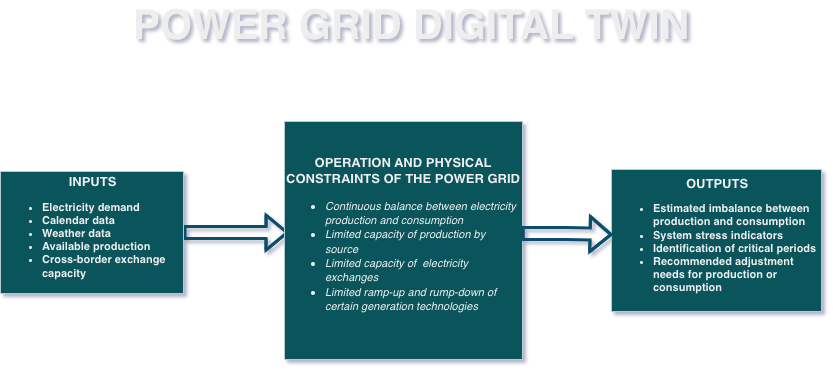

In [ ]:
#Display the image frome Drive
from IPython.display import Image, display
display(Image(filename='/content/drive/MyDrive/Capstone Project - Data & Energy/Project Energy System/Images/DIGITAL TWIN - Power grid.png'))

**P.S. Important concepts:**
- Voltage is the difference in charge between two points (Volt (V)).
- Current is the rate at which charge is flowing (Ampere (A)).
- Resistance is a material's tendency to resist the flow of charge which is the current (Ohm (Ω)).
- Electrical power is the rate at which electrical energy is transferred or consumed at a given moment(Watt(W)).